Overall Accuracy: 0.8596

Classification Report:
               precision    recall  f1-score   support

      Budget       0.91      0.91      0.91       165
     Premium       0.74      0.74      0.74        23
    Standard       0.81      0.81      0.81       104

    accuracy                           0.86       292
   macro avg       0.82      0.82      0.82       292
weighted avg       0.86      0.86      0.86       292



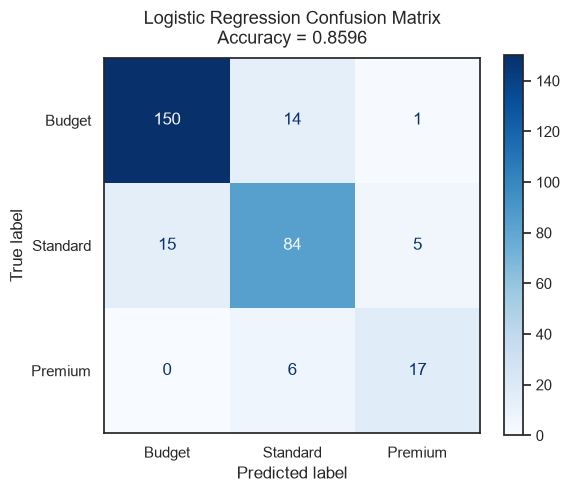

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Load preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# 2. Define features (X) and target (y)
# CRITICAL: Drop 'SalePrice' to prevent deterministic data leakage
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['Price_Category']

# 3. Train-Test Split 
# 'stratify=y' ensures that training and test splits contain identical proportions of each class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Fit Multinomial Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# 5. Make Predictions
y_pred = log_reg.predict(X_test)

# 6. Evaluate Model Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# 7. Generate and Save Confusion Matrix Plot
plt.rc('font', size=11)
sns.set_theme(style='white')

labels_order = ['Budget', 'Standard', 'Premium']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f'Logistic Regression Confusion Matrix\nAccuracy = {accuracy:.4f}', fontsize=13, pad=10)
plt.tight_layout()

# Save image
plt.show()
plt.close()